# Day 4: Swarm-MeZO sweep — (α, β)-family vs Day-3 baselines

Reads `outputs/day4_swarm.json` and overlays with `outputs/day3_consensus.json`.
All runs use the SAME non-IID Dirichlet(α=0.5) split, N=8, K=100, 5000 MeZO
steps — results are directly comparable head-to-head.

Swarm step: θ_i ← (1−α)·θ_i + α·Σ_j softmax(−β·L_j)_j·θ_j

Four plots:

1. **val accuracy / loss vs step** — all Day-3 topologies + all Day-4 swarm
   configs overlaid. The headline: does (α, β) give a configuration that
   beats the doubly-stochastic baselines on non-IID?
2. **Swarm weight heatmap** — for each swarm config, who 'led' each round?
   x=round, y=agent, color=w_j. Reveals whether one agent dominates
   (high β + clean signal) or weights stay distributed (low β or noisy).
3. **Probe-loss curves** — per-agent loss on the fixed 32-sample probe batch
   over rounds, color-coded by class balance. Shows whether specialists
   (e.g. agent 6 with 99% pos) get systematically penalized for being
   class-skewed.
4. **Summary table** — final val_acc, swarm-weight concentration (mean of
   per-round max weight), final probe loss across all configs.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

swarm = json.loads((ROOT / 'outputs' / 'day4_swarm.json').read_text())
day3  = json.loads((ROOT / 'outputs' / 'day3_consensus.json').read_text())

print('swarm config:', {k: v for k, v in swarm['config'].items() if k != 'agent_class_balance'})
print('swarm runs:  ', list(swarm['runs'].keys()))
print('day3 topologies:', list(day3['topologies'].keys()))

N = swarm['config']['n_agents']
class_balance = swarm['config']['agent_class_balance']
print('\nNon-IID per-agent class balance (neg, pos):')
for i, (neg, pos) in enumerate(class_balance):
    pct = pos / (neg + pos) if (neg + pos) else 0.0
    print(f'  agent {i}: neg={neg:3d}, pos={pos:3d}, pos%={pct:.0%}')

plt.rcParams['figure.dpi'] = 110

swarm config: {'model': 'roberta-base', 'train_subset': 1000, 'probe_size': 32, 'total_steps': 5000, 'mezo_lr': 1e-06, 'mezo_eps': 0.001, 'eval_every': 500, 'n_agents': 8, 'local_steps': 100, 'sharding': 'dirichlet', 'dirichlet_alpha': 0.5}
swarm runs:   ['alpha0.5_beta1.0', 'alpha0.5_beta5.0']
day3 topologies: ['full', 'ring', 'star']

Non-IID per-agent class balance (neg, pos):
  agent 0: neg= 27, pos= 24, pos%=47%
  agent 1: neg=  2, pos= 14, pos%=88%
  agent 2: neg=184, pos= 13, pos%=7%
  agent 3: neg= 78, pos= 64, pos%=45%
  agent 4: neg=  5, pos= 25, pos%=83%
  agent 5: neg= 18, pos=  3, pos%=14%
  agent 6: neg=  4, pos=415, pos%=99%
  agent 7: neg=122, pos=  2, pos%=2%


## Plot 1 — val accuracy / loss: Swarm vs Day-3 baselines

Overlay all available curves so the (α, β)-family can be read against
the doubly-stochastic baselines (full = FedAvg = α=1,β=0; ring, star).
Warm colors = Day-4 swarm, cool colors = Day-3 baselines.

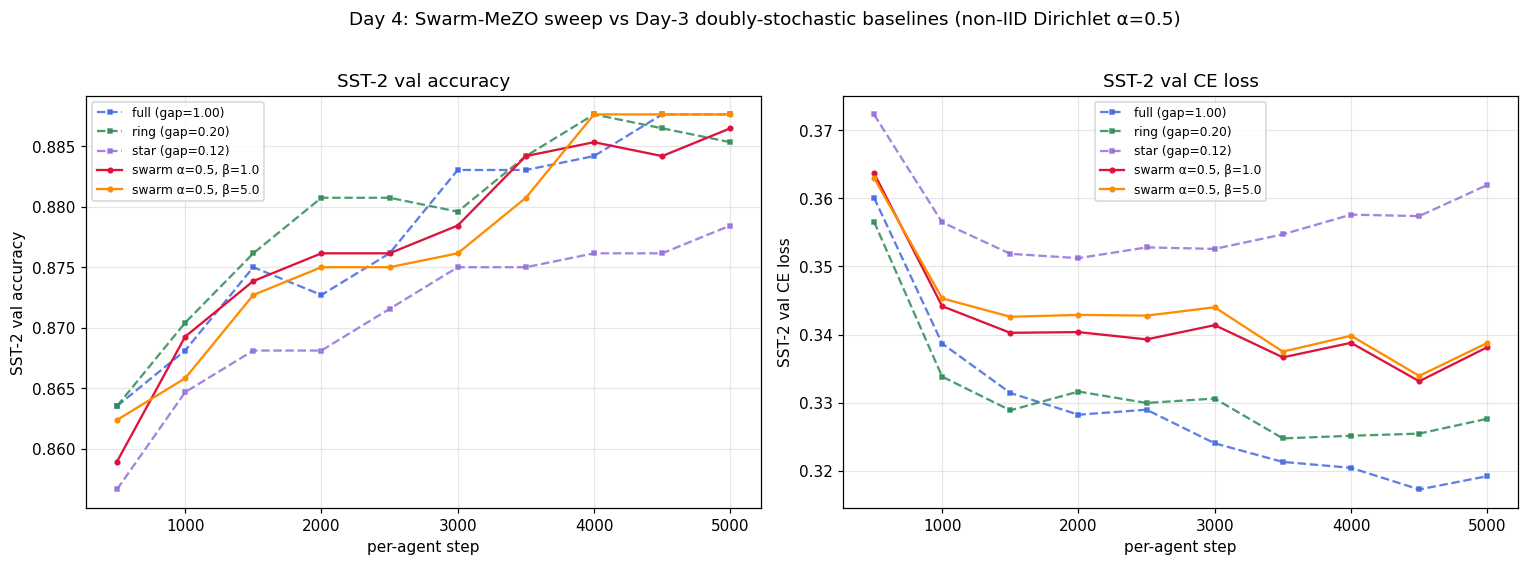

In [2]:
day3_colors = {'full': 'royalblue', 'ring': 'seagreen', 'star': 'mediumpurple'}
swarm_colors = ['crimson', 'darkorange', 'goldenrod', 'sienna', 'firebrick']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, ylabel in [
    (axes[0], 'eval_acc',  'SST-2 val accuracy'),
    (axes[1], 'eval_loss', 'SST-2 val CE loss'),
]:
    # Day 3 baselines (doubly-stochastic consensus).
    for name, h in day3['topologies'].items():
        meta = day3['topology_meta'][name]
        ax.plot(h['eval_step'], h[key], marker='s', markersize=3, linestyle='--',
                color=day3_colors.get(name, 'gray'), alpha=0.85,
                label=f"{name} (gap={meta['spectral_gap']:.2f})")
    # Day 4 swarm configs.
    for i, (name, h) in enumerate(swarm['runs'].items()):
        ax.plot(h['eval_step'], h[key], marker='o', markersize=3,
                color=swarm_colors[i % len(swarm_colors)],
                label=f"swarm α={h['alpha']}, β={h['beta']}")
    ax.set_xlabel('per-agent step'); ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel}"); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Day 4: Swarm-MeZO sweep vs Day-3 doubly-stochastic baselines (non-IID Dirichlet α=0.5)', y=1.02)
plt.tight_layout()

## Plot 2 — swarm weight heatmap ("who led each round")

For each swarm config, a heatmap of softmax weights w_j over consensus
rounds. Bright = agent led that round, dark = ignored.

- Low β → weights stay near 1/N=0.125 → heatmap is uniform.
- High β → one row dominates each column → sparse bright pattern.
- If the same agent dominates every round, the swarm has effectively
  collapsed to ES with that agent as the parent.

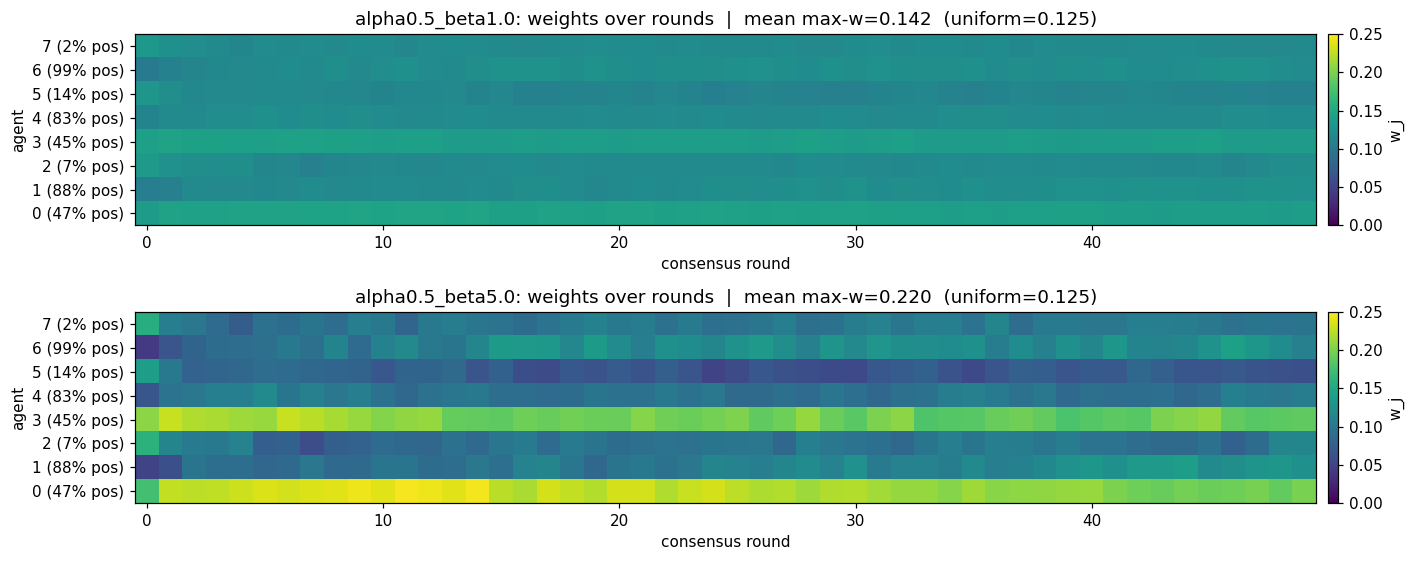

In [3]:
n_runs = len(swarm['runs'])
if n_runs == 0:
    print('no swarm runs yet')
else:
    fig, axes = plt.subplots(n_runs, 1, figsize=(13, 2.6 * n_runs), squeeze=False)
    uniform = 1.0 / N
    for i, (name, h) in enumerate(swarm['runs'].items()):
        ax = axes[i, 0]
        W = np.asarray(h['swarm_weights'])           # (rounds, N)
        if W.size == 0:
            ax.text(0.5, 0.5, f'{name}: no rounds recorded', ha='center', transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([]); continue
        im = ax.imshow(W.T, aspect='auto', cmap='viridis',
                       vmin=0, vmax=max(W.max(), 2 * uniform), origin='lower')
        ax.set_xlabel('consensus round'); ax.set_ylabel('agent')
        ax.set_yticks(range(N))
        ax.set_yticklabels([f"{j} ({class_balance[j][1] / sum(class_balance[j]):.0%} pos)" for j in range(N)])
        max_w_mean = float(W.max(axis=1).mean())
        ax.set_title(f"{name}: weights over rounds  |  mean max-w={max_w_mean:.3f}  (uniform={uniform:.3f})")
        plt.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label='w_j')
    plt.tight_layout()

## Plot 3 — per-agent probe loss over rounds

The fitness signal used by the swarm. Dashed reference line = uniform-noise
baseline (≈ 0.693 = ln 2 — random binary prediction). Curves below it mean
the agent learned something on the probe set; the spread between curves is
what β amplifies into selection pressure.

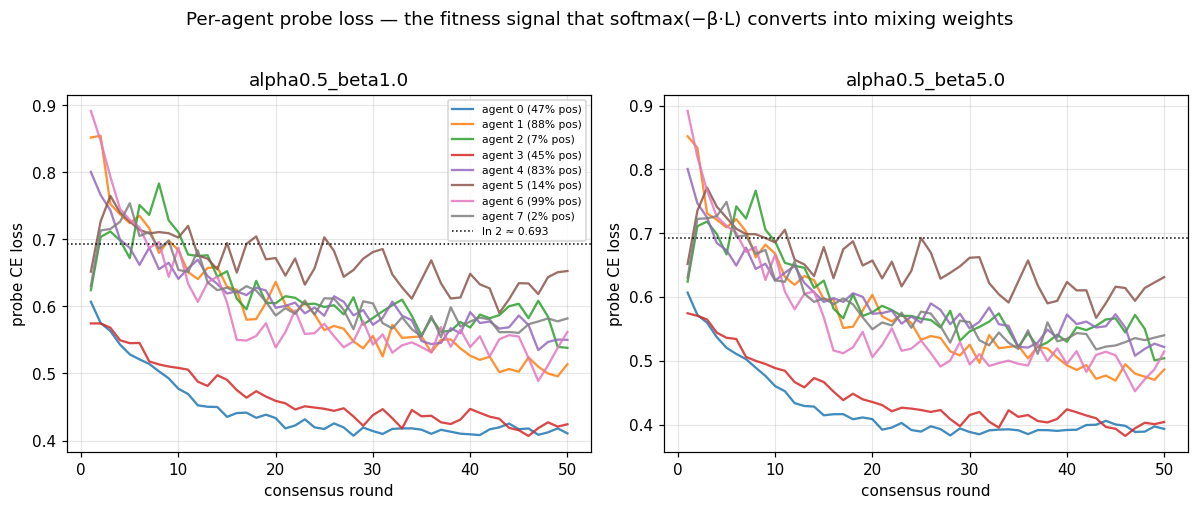

In [4]:
if n_runs == 0:
    print('no swarm runs yet')
else:
    fig, axes = plt.subplots(1, n_runs, figsize=(5.5 * n_runs, 4.5), squeeze=False)
    agent_cmap = plt.get_cmap('tab10')
    for i, (name, h) in enumerate(swarm['runs'].items()):
        ax = axes[0, i]
        L = np.asarray(h['swarm_eval_losses'])       # (rounds, N)
        if L.size == 0:
            ax.text(0.5, 0.5, 'no probe losses recorded', ha='center', transform=ax.transAxes)
            continue
        rounds = np.arange(1, L.shape[0] + 1)
        for j in range(N):
            ax.plot(rounds, L[:, j], color=agent_cmap(j), alpha=0.85,
                    label=f"agent {j} ({class_balance[j][1] / sum(class_balance[j]):.0%} pos)")
        ax.axhline(np.log(2), color='black', linestyle=':', linewidth=1, label=f'ln 2 ≈ {np.log(2):.3f}')
        ax.set_xlabel('consensus round'); ax.set_ylabel('probe CE loss')
        ax.set_title(f"{name}"); ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=7, loc='upper right')
    plt.suptitle('Per-agent probe loss — the fitness signal that softmax(−β·L) converts into mixing weights', y=1.02)
    plt.tight_layout()

## Plot 4 — summary table

All comparable runs in one place: final val_acc, swarm-weight concentration
(higher = more like winner-take-all), and — for Day 3 — contraction rate vs
theoretical |λ₂|. For sorting, "diversity score" measures how far per-round
weights stay from uniform (0 = pure FedAvg, 1 = winner-take-all).

In [5]:
rows = []
uniform = 1.0 / N

# Day 3 baselines.
for name, h in day3['topologies'].items():
    meta = day3['topology_meta'][name]
    db = np.asarray(h['consensus_dist_before'])
    da = np.asarray(h['consensus_dist_after'])
    pos = (db > 1e-12) & (da > 1e-12)
    if pos.any():
        emp_rate = float(np.exp(np.log(da[pos] / db[pos]).mean()))
    else:
        emp_rate = 0.0
    rows.append({
        'config':              name,
        'family':              'Day 3 doubly-stochastic',
        'α':                   None,
        'β':                   None,
        'final val_acc':       round(h['eval_acc'][-1], 4),
        'final probe loss':    None,
        'mean max-w':          None,
        'diversity_score':     None,
        'theoretical |λ₂|':    round(meta['second_eigenvalue'], 4),
        'empirical contract.': round(emp_rate, 4),
    })

# Day 4 swarm runs.
for name, h in swarm['runs'].items():
    W = np.asarray(h['swarm_weights'])
    L = np.asarray(h['swarm_eval_losses'])
    if W.size > 0:
        max_w_mean = float(W.max(axis=1).mean())
        # Diversity score: distance from uniform, normalized to [0, 1].
        # 0 = uniform (FedAvg-like). 1 = winner-take-all (one agent has w=1).
        diversity = float(((W.max(axis=1) - uniform) / (1.0 - uniform)).mean())
    else:
        max_w_mean = None
        diversity = None
    probe_final = float(L[-1].mean()) if L.size > 0 else None
    rows.append({
        'config':              name,
        'family':              'Day 4 swarm',
        'α':                   h['alpha'],
        'β':                   h['beta'],
        'final val_acc':       round(h['eval_acc'][-1], 4),
        'final probe loss':    round(probe_final, 4) if probe_final is not None else None,
        'mean max-w':          round(max_w_mean, 4) if max_w_mean is not None else None,
        'diversity_score':     round(diversity, 4) if diversity is not None else None,
        'theoretical |λ₂|':    None,
        'empirical contract.': None,
    })

df = pd.DataFrame(rows)
df = df.sort_values('final val_acc', ascending=False).reset_index(drop=True)
df

,config,family,α,β,final val_acc,final probe loss,mean max-w,diversity_score,theoretical |λ₂|,empirical contract.
0,full,Day 3 doubly-stochastic,NaN,NaN,0.8876,NaN,NaN,NaN,0.0000,0.0000
1,alpha0.5_beta5.0,Day 4 swarm,0.5,5.0,0.8876,0.4996,0.2202,0.1088,NaN,NaN
2,alpha0.5_beta1.0,Day 4 swarm,0.5,1.0,0.8865,0.5292,0.1424,0.0199,NaN,NaN
3,ring,Day 3 doubly-stochastic,NaN,NaN,0.8853,NaN,NaN,NaN,0.8047,0.6032
4,star,Day 3 doubly-stochastic,NaN,NaN,0.8784,NaN,NaN,NaN,0.8750,0.8548
